<a href="https://colab.research.google.com/github/yasaswini1408/Prompt_Engineering/blob/main/Experiment8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langgraph langchain-google-genai langchain_core


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.8/72.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 13.8 MB/s eta 0:00:00
  Attempting uninstall: langchain_core
    Found existing installation: langchain-core 1.4.9
    Uninstalling langchain-core-1.4.9:
      Successfully uninstalled langchain-core-1.4.9


In [2]:
import os
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver
from google.colab import userdata
from IPython.display import Image, display

In [4]:
os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", temperature=0.3)
# Define custom LangGraph state tracking message history
class State(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]

In [5]:
def assistant_node(state: State):
  """Executes the LLM call using the accumulated message history."""
  response = llm.invoke(state["messages"])
  return {"messages": [response]}

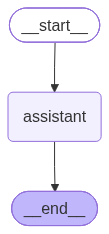

In [6]:
builder = StateGraph(State)
# Define node and connect the graph flow structure
builder.add_node("assistant", assistant_node)
builder.add_edge(START, "assistant")
builder.add_edge("assistant", END)
# Set up durable memory checkpointing to handle distinct user histories
memory = MemorySaver()
compiled_graph = builder.compile(checkpointer=memory)
# Render and display the visualization of the graph topology
display(Image(compiled_graph.get_graph().draw_mermaid_png()))

In [ ]:
print("--- LangGraph Multi-User Stateful Chat Engine ---")
print("Instructions: Type your message normally.")
print("To switch users, type: /user <id> (e.g., /user user_1 or /user user_2)")
print("To stop, type: exit\n")
# Default active session ID at startup
current_user = "user_1"
while True:
  user_input = input(f"[{current_user}] User Input: ").strip()
  if user_input.lower() == 'exit':
    print("Shutting down conversational engine.")
    break
    # Check if the user is trying to switch accounts/threads
  if user_input.startswith("/user "):
    new_user = user_input.split(" ")[1].strip()
    if new_user:
      current_user = new_user
      print(f" >> Switched active execution context to: {current_user}\n")
      continue
  if not user_input:
      continue      # Pack the runtime thread configuration dynamically
  config = {"configurable": {"thread_id": current_user}}
      # Create the human message object
  new_message = HumanMessage(content=user_input)
      # Run the graph and stream/extract the output snapshot
  output_state = compiled_graph.invoke({"messages": [new_message]}, config)
      # Print the last message added to the state (the AI's response)
  print(f"Assistant: {output_state['messages'][-1].content[0]["text"]}\n")

--- LangGraph Multi-User Stateful Chat Engine ---
Instructions: Type your message normally.
To switch users, type: /user <id> (e.g., /user user_1 or /user user_2)
To stop, type: exit

[user_1] User Input: Hi this is sainadh, What is the capitol of Indonesia?
Assistant: Hi Sainadh! The current capital of Indonesia is **Jakarta**.

However, it is worth noting that the Indonesian government is in the process of moving the capital to a new city called **Nusantara**, located on the island of Borneo. While the transition is underway, Jakarta remains the official capital for now.

[user_1] User Input: What is the capitol of Brazil? 
Assistant: The capital of Brazil is **Brasília**.

[user_1] User Input:  Hi this is Karthik, Where is tajmahal? 
Assistant: Hi Karthik! The Taj Mahal is located in the city of **Agra**, in the state of Uttar Pradesh, **India**.

[user_1] User Input: Can you tell me the currency of China? 
Assistant: The currency of China is the **renminbi** (RMB). 

The basic unit